# REGRESIÓN LOGÍSTICA - PREDICCIÓN DE ABANDONO

**Asignatura:** Minería de Datos  
**Dataset:** OULAD - studentInfo.csv  

## Objetivo

Construir un modelo de regresión logística que permita clasificar a los
estudiantes según su riesgo de abandono académico, utilizando variables
disponibles en el dataset OULAD.

Se define:

- abandono = 1 → estudiante con `final_result = Withdrawn`
- abandono = 0 → estudiante con otro resultado

In [1]:
%pip install statsmodels

Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [3]:
# Librerías principales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Regresión logística
import statsmodels.api as sm

# División de datos
from sklearn.model_selection import train_test_split

# Métricas
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

pd.set_option('display.max_columns', None)

In [4]:
df = pd.read_csv('../Data/studentInfo.csv')

print("Dimensiones:", df.shape)
df.head()

Dimensiones: (32593, 12)


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass


In [5]:
# Crear variable objetivo
df['abandono'] = (df['final_result'] == 'Withdrawn').astype(int)

df[['final_result', 'abandono']].head(10)

,final_result,abandono
0,Pass,0
1,Pass,0
2,Withdrawn,1
3,Pass,0
4,Pass,0
5,Pass,0
6,Pass,0
7,Pass,0
8,Pass,0
9,Pass,0


In [6]:
df['abandono'].value_counts()

abandono
0    22437
1    10156
Name: count, dtype: int64

In [7]:
df['abandono'].value_counts(normalize=True) * 100

abandono
0    68.839935
1    31.160065
Name: proportion, dtype: float64

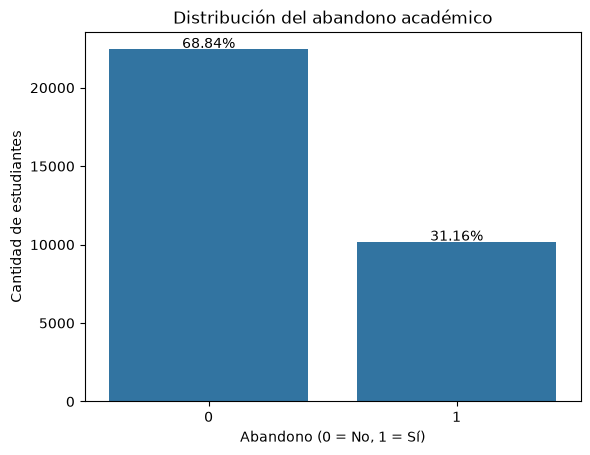

In [8]:
ax = sns.countplot(x='abandono', data=df)

total = len(df)

for p in ax.patches:
    height = p.get_height()

    ax.text(
        p.get_x() + p.get_width()/2,
        height + 100,
        f'{height/total:.2%}',
        ha='center'
    )

plt.title('Distribución del abandono académico')
plt.xlabel('Abandono (0 = No, 1 = Sí)')
plt.ylabel('Cantidad de estudiantes')
plt.show()

## Selección de variables para la primera iteración

La variable objetivo del modelo es `abandono`:

- 0 = No abandono
- 1 = Abandono

Para la primera iteración se utilizarán como variables explicativas:

- `num_of_prev_attempts`: número de intentos previos del estudiante.
- `studied_credits`: cantidad de créditos estudiados.

La variable `final_result` no se utiliza como variable predictora porque fue
utilizada para construir la variable objetivo `abandono`, lo que produciría
fuga de información (data leakage).

In [9]:
# Variable objetivo
y = df['abandono']

# Variables explicativas
X = df[
    [
        'num_of_prev_attempts',
        'studied_credits'
    ]
].copy()

X.head()

,num_of_prev_attempts,studied_credits
0,0,240
1,0,60
2,0,60
3,0,60
4,0,60


In [10]:
X.isnull().sum()

num_of_prev_attempts    0
studied_credits         0
dtype: int64

In [11]:
y.isnull().sum()

np.int64(0)

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=777,
    stratify=y
)

In [13]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (26074, 2)
X_test : (6519, 2)
y_train: (26074,)
y_test : (6519,)


In [14]:
print("Abandono en TRAIN:")
print(y_train.value_counts(normalize=True) * 100)

print("\nAbandono en TEST:")
print(y_test.value_counts(normalize=True) * 100)

Abandono en TRAIN:
abandono
0    68.83869
1    31.16131
Name: proportion, dtype: float64

Abandono en TEST:
abandono
0    68.844915
1    31.155085
Name: proportion, dtype: float64


In [15]:
X_train_sm = sm.add_constant(X_train)

X_train_sm.head()

,const,num_of_prev_attempts,studied_credits
9704,1.0,0,60
7280,1.0,0,180
26593,1.0,0,60
7641,1.0,0,60
29510,1.0,0,60


In [16]:
modelo_logit = sm.Logit(
    y_train,
    X_train_sm
).fit()

Optimization terminated successfully.
         Current function value: 0.602154
         Iterations 5


In [17]:
print(modelo_logit.summary())

                           Logit Regression Results                           
Dep. Variable:               abandono   No. Observations:                26074
Model:                          Logit   Df Residuals:                    26071
Method:                           MLE   Df Model:                            2
Date:                Sat, 19 Sep 2026   Pseudo R-squ.:                 0.02939
Time:                        10:46:37   Log-Likelihood:                -15701.
converged:                       True   LL-Null:                       -16176.
Covariance Type:            nonrobust   LLR p-value:                3.588e-207
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   -1.6079      0.031    -52.078      0.000      -1.668      -1.547
num_of_prev_attempts    -0.0304      0.029     -1.064      0.287      -0.086       0.026
studied_cred

## Interpretación inicial del modelo

El modelo de regresión logística fue entrenado con 26.074 registros y
convergió correctamente.

En esta primera iteración se observa que:

- `studied_credits` presenta un coeficiente positivo de 0.0100 y un
  valor p menor a 0.05, por lo que muestra una asociación
  estadísticamente significativa con la probabilidad de abandono.

- `num_of_prev_attempts` presenta un coeficiente de -0.0304 y un
  valor p de 0.287. Al ser mayor a 0.05, no presenta evidencia
  suficiente de una asociación estadísticamente significativa con
  el abandono en esta primera iteración.

El Pseudo R² obtenido es 0.02939, lo que indica que el modelo inicial,
formado únicamente por dos variables explicativas, posee una capacidad
explicativa limitada. Por esta razón, posteriormente será necesario
evaluar nuevas variables en una segunda iteración.

In [18]:
# Probabilidades de abandono en los datos de entrenamiento
y_prob_train = modelo_logit.predict(X_train_sm)

y_prob_train.head()

9704     0.266930
7280     0.546123
26593    0.266930
7641     0.266930
29510    0.266930
dtype: float64

In [19]:
# Convertir probabilidades a clases utilizando un umbral de 0.50
y_pred_train = (y_prob_train >= 0.50).astype(int)

y_pred_train.head()

9704     0
7280     1
26593    0
7641     0
29510    0
dtype: int64

In [20]:
print("RESULTADOS - TRAIN")
print("------------------------------")

print(f"Accuracy : {accuracy_score(y_train, y_pred_train):.4f}")
print(f"Precision: {precision_score(y_train, y_pred_train, zero_division=0):.4f}")
print(f"Recall   : {recall_score(y_train, y_pred_train, zero_division=0):.4f}")
print(f"F1-Score : {f1_score(y_train, y_pred_train, zero_division=0):.4f}")
print(f"AUC      : {roc_auc_score(y_train, y_prob_train):.4f}")

RESULTADOS - TRAIN
------------------------------
Accuracy : 0.6944
Precision: 0.5682
Recall   : 0.0800
F1-Score : 0.1403
AUC      : 0.6085


In [21]:
matriz_train = confusion_matrix(y_train, y_pred_train)

print("Matriz de confusión - TRAIN")
print(matriz_train)

Matriz de confusión - TRAIN
[[17455   494]
 [ 7475   650]]


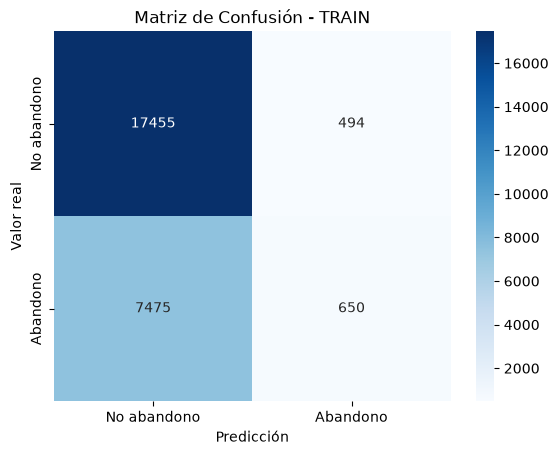

In [22]:
sns.heatmap(
    matriz_train,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No abandono', 'Abandono'],
    yticklabels=['No abandono', 'Abandono']
)

plt.title('Matriz de Confusión - TRAIN')
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.show()

In [23]:
# Agregar constante a los datos de prueba
X_test_sm = sm.add_constant(X_test)

# Obtener probabilidades
y_prob_test = modelo_logit.predict(X_test_sm)

y_prob_test.head()

22232    0.212641
12467    0.398284
1602     0.398284
13149    0.266930
24476    0.266930
dtype: float64

In [24]:
# Convertir probabilidades en clases
y_pred_test = (y_prob_test >= 0.50).astype(int)

In [25]:
print("RESULTADOS - TEST")
print("------------------------------")

print(f"Accuracy : {accuracy_score(y_test, y_pred_test):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_test, zero_division=0):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_test, zero_division=0):.4f}")
print(f"F1-Score : {f1_score(y_test, y_pred_test, zero_division=0):.4f}")
print(f"AUC      : {roc_auc_score(y_test, y_prob_test):.4f}")

RESULTADOS - TEST
------------------------------
Accuracy : 0.6908
Precision: 0.5309
Recall   : 0.0635
F1-Score : 0.1135
AUC      : 0.6015


In [26]:
matriz_test = confusion_matrix(y_test, y_pred_test)

print("Matriz de confusión - TEST")
print(matriz_test)

Matriz de confusión - TEST
[[4374  114]
 [1902  129]]


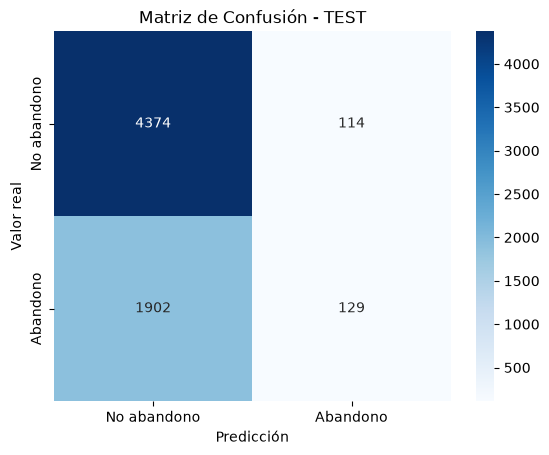

In [27]:
sns.heatmap(
    matriz_test,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No abandono', 'Abandono'],
    yticklabels=['No abandono', 'Abandono']
)

plt.title('Matriz de Confusión - TEST')
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.show()

In [28]:
print(
    classification_report(
        y_test,
        y_pred_test,
        target_names=['No abandono', 'Abandono'],
        zero_division=0
    )
)

              precision    recall  f1-score   support

 No abandono       0.70      0.97      0.81      4488
    Abandono       0.53      0.06      0.11      2031

    accuracy                           0.69      6519
   macro avg       0.61      0.52      0.46      6519
weighted avg       0.65      0.69      0.59      6519



## Conclusión de la primera iteración

La primera iteración del modelo de Regresión Logística utilizó las variables
`num_of_prev_attempts` y `studied_credits` para clasificar el abandono académico.

En el conjunto de prueba se obtuvo un Accuracy de 0.6908 y un AUC de 0.6015.
Sin embargo, el Recall para la clase abandono fue únicamente de 0.0635.

La matriz de confusión muestra que, de 2.031 casos reales de abandono,
el modelo identificó correctamente 129 y no detectó 1.902.

Por tanto, aunque el Accuracy alcanza aproximadamente el 69 %, esta métrica
por sí sola no representa adecuadamente el desempeño del modelo debido a
la distribución de las clases. La primera iteración presenta una capacidad
limitada para detectar estudiantes en situación de abandono.

Los resultados justifican realizar una segunda iteración incorporando
más variables explicativas disponibles en el dataset.

In [29]:
accuracy_base = y_test.value_counts(normalize=True).max()

print(f"Accuracy del modelo : {accuracy_score(y_test, y_pred_test):.4f}")
print(f"Accuracy base       : {accuracy_base:.4f}")

Accuracy del modelo : 0.6908
Accuracy base       : 0.6884


In [30]:
variables_segunda_iteracion = [
    'code_module',
    'code_presentation',
    'gender',
    'region',
    'highest_education',
    'imd_band',
    'age_band',
    'num_of_prev_attempts',
    'studied_credits',
    'disability'
]

X2 = df[variables_segunda_iteracion].copy()

X2.head()

,code_module,code_presentation,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability
0,AAA,2013J,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N
1,AAA,2013J,F,Scotland,HE Qualification,20-30%,35-55,0,60,N
2,AAA,2013J,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y
3,AAA,2013J,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N
4,AAA,2013J,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N


In [31]:
X2.isnull().sum()

code_module                0
code_presentation          0
gender                     0
region                     0
highest_education          0
imd_band                1111
age_band                   0
num_of_prev_attempts       0
studied_credits            0
disability                 0
dtype: int64

In [32]:
X2['imd_band'] = X2['imd_band'].fillna('Unknown')

X2.isnull().sum()

code_module             0
code_presentation       0
gender                  0
region                  0
highest_education       0
imd_band                0
age_band                0
num_of_prev_attempts    0
studied_credits         0
disability              0
dtype: int64

In [34]:
columnas_categoricas = X2.select_dtypes(include='str').columns

print("Variables categóricas:")
print(columnas_categoricas)

Variables categóricas:
Index(['code_module', 'code_presentation', 'gender', 'region',
       'highest_education', 'imd_band', 'age_band', 'disability'],
      dtype='str')


In [35]:
X2 = pd.get_dummies(
    X2,
    columns=columnas_categoricas,
    drop_first=True,
    dtype=int
)

print("Dimensiones después de codificar:", X2.shape)
X2.head()

Dimensiones después de codificar: (32593, 41)


,num_of_prev_attempts,studied_credits,code_module_BBB,code_module_CCC,code_module_DDD,code_module_EEE,code_module_FFF,code_module_GGG,code_presentation_2013J,code_presentation_2014B,code_presentation_2014J,gender_M,region_East Midlands Region,region_Ireland,region_London Region,region_North Region,region_North Western Region,region_Scotland,region_South East Region,region_South Region,region_South West Region,region_Wales,region_West Midlands Region,region_Yorkshire Region,highest_education_HE Qualification,highest_education_Lower Than A Level,highest_education_No Formal quals,highest_education_Post Graduate Qualification,imd_band_10-20,imd_band_20-30%,imd_band_30-40%,imd_band_40-50%,imd_band_50-60%,imd_band_60-70%,imd_band_70-80%,imd_band_80-90%,imd_band_90-100%,imd_band_Unknown,age_band_35-55,age_band_55<=,disability_Y
0,0,240,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0
1,0,60,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0
2,0,60,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,1
3,0,60,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0
4,0,60,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0


In [36]:
print(X2.dtypes.value_counts())

int64    41
Name: count, dtype: int64


In [37]:
X2.head()

,num_of_prev_attempts,studied_credits,code_module_BBB,code_module_CCC,code_module_DDD,code_module_EEE,code_module_FFF,code_module_GGG,code_presentation_2013J,code_presentation_2014B,code_presentation_2014J,gender_M,region_East Midlands Region,region_Ireland,region_London Region,region_North Region,region_North Western Region,region_Scotland,region_South East Region,region_South Region,region_South West Region,region_Wales,region_West Midlands Region,region_Yorkshire Region,highest_education_HE Qualification,highest_education_Lower Than A Level,highest_education_No Formal quals,highest_education_Post Graduate Qualification,imd_band_10-20,imd_band_20-30%,imd_band_30-40%,imd_band_40-50%,imd_band_50-60%,imd_band_60-70%,imd_band_70-80%,imd_band_80-90%,imd_band_90-100%,imd_band_Unknown,age_band_35-55,age_band_55<=,disability_Y
0,0,240,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0
1,0,60,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0
2,0,60,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,1
3,0,60,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0
4,0,60,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0


In [38]:
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2,
    y,
    test_size=0.20,
    random_state=777,
    stratify=y
)

print("X2_train:", X2_train.shape)
print("X2_test :", X2_test.shape)

X2_train: (26074, 41)
X2_test : (6519, 41)


In [39]:
X2_train_sm = sm.add_constant(X2_train)

modelo_logit_2 = sm.Logit(
    y2_train,
    X2_train_sm
).fit(maxiter=200)

Optimization terminated successfully.
         Current function value: 0.577620
         Iterations 6


In [40]:
print(modelo_logit_2.summary())

                           Logit Regression Results                           
Dep. Variable:               abandono   No. Observations:                26074
Model:                          Logit   Df Residuals:                    26032
Method:                           MLE   Df Model:                           41
Date:                Sat, 19 Sep 2026   Pseudo R-squ.:                 0.06893
Time:                        10:58:19   Log-Likelihood:                -15061.
converged:                       True   LL-Null:                       -16176.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                    coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------
const                                            -2.4206      0.143    -16.982      0.000      -2.700      -2.141
num_of_prev_attempts      

## Interpretación de la segunda iteración

La segunda iteración del modelo incorporó variables académicas,
demográficas y contextuales adicionales.

El modelo convergió correctamente y presentó un Pseudo R² de 0.06893,
superior al valor de 0.02939 obtenido en la primera iteración, lo que
evidencia una mejora en el ajuste relativo del modelo.

El LLR p-value fue menor a 0.05, indicando que el conjunto de variables
incorporadas aporta información estadísticamente significativa para
modelar el abandono académico.

Entre las variables con categorías estadísticamente significativas se
encuentran el módulo cursado, la presentación del curso, género, algunas
regiones, nivel educativo previo, nivel IMD, créditos estudiados y
discapacidad.

Sin embargo, otras variables como `num_of_prev_attempts` y las categorías
de edad no presentan significancia estadística en esta iteración.

Los coeficientes de las variables categóricas deben interpretarse en
relación con sus respectivas categorías de referencia, debido a que se
utilizó codificación dummy con `drop_first=True`.

In [41]:
# Preparar los datos de prueba
X2_test_sm = sm.add_constant(
    X2_test,
    has_constant='add'
)

# Probabilidad estimada de abandono
y2_prob_test = modelo_logit_2.predict(X2_test_sm)

y2_prob_test.head()

22232    0.178905
12467    0.473462
1602     0.481758
13149    0.281303
24476    0.209669
dtype: float64

In [42]:
# Clasificación utilizando umbral de 0.50
y2_pred_test = (y2_prob_test >= 0.50).astype(int)

y2_pred_test.head()

22232    0
12467    0
1602     0
13149    0
24476    0
dtype: int64

In [43]:
print("SEGUNDA ITERACIÓN - TEST")
print("--------------------------------")

print(f"Accuracy : {accuracy_score(y2_test, y2_pred_test):.4f}")
print(f"Precision: {precision_score(y2_test, y2_pred_test, zero_division=0):.4f}")
print(f"Recall   : {recall_score(y2_test, y2_pred_test, zero_division=0):.4f}")
print(f"F1-Score : {f1_score(y2_test, y2_pred_test, zero_division=0):.4f}")
print(f"AUC      : {roc_auc_score(y2_test, y2_prob_test):.4f}")

SEGUNDA ITERACIÓN - TEST
--------------------------------
Accuracy : 0.7047
Precision: 0.5940
Recall   : 0.1649
F1-Score : 0.2582
AUC      : 0.6763


In [44]:
matriz_test_2 = confusion_matrix(
    y2_test,
    y2_pred_test
)

print("Matriz de confusión - Segunda iteración")
print(matriz_test_2)

Matriz de confusión - Segunda iteración
[[4259  229]
 [1696  335]]


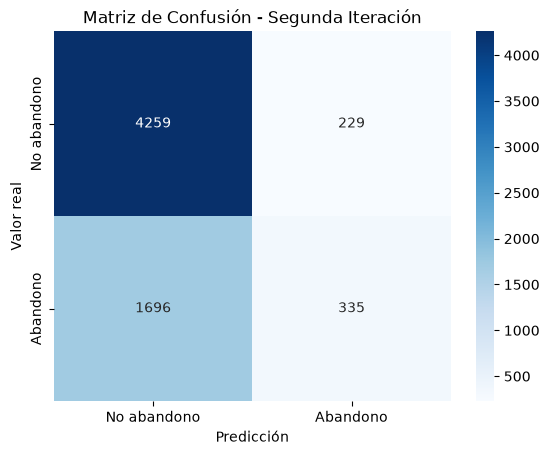

In [45]:
sns.heatmap(
    matriz_test_2,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No abandono', 'Abandono'],
    yticklabels=['No abandono', 'Abandono']
)

plt.title('Matriz de Confusión - Segunda Iteración')
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.show()

In [46]:
print(
    classification_report(
        y2_test,
        y2_pred_test,
        target_names=['No abandono', 'Abandono'],
        zero_division=0
    )
)

              precision    recall  f1-score   support

 No abandono       0.72      0.95      0.82      4488
    Abandono       0.59      0.16      0.26      2031

    accuracy                           0.70      6519
   macro avg       0.65      0.56      0.54      6519
weighted avg       0.68      0.70      0.64      6519



## Comparación de las iteraciones

La incorporación de variables académicas, demográficas y contextuales
mejoró el desempeño del modelo respecto a la primera iteración.

Para la clase abandono, la precisión aumentó aproximadamente de 0.53 a 0.59,
el Recall de 0.06 a 0.16 y el F1-score de 0.11 a 0.26.

El Accuracy global también aumentó ligeramente hasta aproximadamente 0.70.

La mejora más importante se observa en la capacidad de detectar casos de
abandono. Sin embargo, un Recall de 0.16 continúa siendo bajo, ya que el
modelo todavía clasifica como no abandono a una proporción considerable de
estudiantes que realmente abandonan.

Por esta razón, se evaluará el efecto del umbral de clasificación sobre
Precision, Recall y F1-score.

In [47]:
resultados_umbral = []

for umbral in [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:

    pred = (y2_prob_test >= umbral).astype(int)

    resultados_umbral.append({
        'Umbral': umbral,
        'Accuracy': accuracy_score(y2_test, pred),
        'Precision': precision_score(y2_test, pred, zero_division=0),
        'Recall': recall_score(y2_test, pred, zero_division=0),
        'F1': f1_score(y2_test, pred, zero_division=0)
    })

tabla_umbrales = pd.DataFrame(resultados_umbral)

tabla_umbrales

,Umbral,Accuracy,Precision,Recall,F1
0,0.20,0.457432,0.354183,0.900542,0.508409
1,0.25,0.539653,0.384303,0.793205,0.517757
2,0.30,0.610830,0.419632,0.650419,0.510137
3,0.35,0.664059,0.463715,0.500246,0.481288
4,0.40,0.701641,0.529533,0.379616,0.442214
5,0.45,0.706090,0.562297,0.255539,0.351388
6,0.50,0.704709,0.593972,0.164943,0.258189


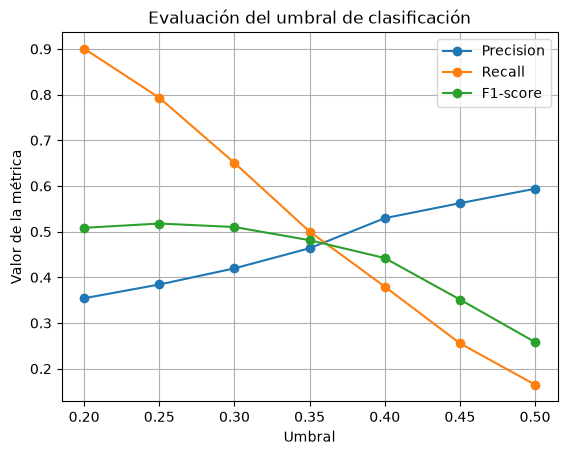

In [48]:
plt.plot(
    tabla_umbrales['Umbral'],
    tabla_umbrales['Precision'],
    marker='o',
    label='Precision'
)

plt.plot(
    tabla_umbrales['Umbral'],
    tabla_umbrales['Recall'],
    marker='o',
    label='Recall'
)

plt.plot(
    tabla_umbrales['Umbral'],
    tabla_umbrales['F1'],
    marker='o',
    label='F1-score'
)

plt.xlabel('Umbral')
plt.ylabel('Valor de la métrica')
plt.title('Evaluación del umbral de clasificación')
plt.legend()
plt.grid()
plt.show()

In [49]:
mejor = tabla_umbrales.loc[
    tabla_umbrales['F1'].idxmax()
]

print("Mejor resultado según F1:")
print(mejor)

Mejor resultado según F1:
Umbral       0.250000
Accuracy     0.539653
Precision    0.384303
Recall       0.793205
F1           0.517757
Name: 1, dtype: float64
